In [1]:
import pandas as pd
from rapidfuzz.distance import Levenshtein
from tqdm.notebook import tqdm
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import chess
from IPython.display import display, HTML
from statsmodels.stats.proportion import proportion_confint
from metrics.diversity_filtering import fen_to_padded
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import balanced_accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from natsort import natsorted


In [ ]:
total = 0
for param in model.parameters():
    total += param.numel()
total

268892160

In [28]:
df = pd.read_csv(Path("./Generate_positions/arxiv_true/lichess.csv"))

cols = {"legal rate": df["is_legal"], "uniqueness rate": df["is_puzzle"], "counter-intuitive rate given unique": df[df["is_puzzle"]]["counter_intuitive"], "puzzle rate": df["is_puzzle"] & df["counter_intuitive"]}
for name, col in cols.items():
    lower_bound, upper_bound = proportion_confint(count=col.sum(), nobs=len(df), alpha=0.05, method="normal")
    lower_bound, upper_bound = 100 * lower_bound, 100 * upper_bound
    print(name, 100 * col.mean(), [lower_bound, upper_bound], (upper_bound - lower_bound) / 2)


legal rate 100.0 [100.0, 100.0] 0.0
uniqueness rate 94.2375 [94.1353706799388, 94.33962932006119] 0.10212932006119502
counter-intuitive rate given unique 2.2390237432020164 [2.0470140788607942, 2.1729859211392055] 0.06298592113920565
puzzle rate 2.11 [2.0470140788607942, 2.1729859211392055] 0.06298592113920565


In [2]:
base_path = Path("./Generate_positions/Lichess")
for path in os.listdir(base_path):
    if path[-4:] != ".csv":
        continue
    df = pd.read_csv(base_path / path)

    print("===================== " + path[:-4] + " =====================")

    cols = {"legal rate": df["is_legal"], "uniqueness rate": df["is_puzzle"], "counter-intuitive rate given unique": df[df["is_puzzle"]]["counter_intuitive"], "puzzle rate": df["is_puzzle"] & df["counter_intuitive"]}
    for name, col in cols.items():
        lower_bound, upper_bound = proportion_confint(count=col.sum(), nobs=len(df), alpha=0.05, method="normal")
        lower_bound, upper_bound = 100 * lower_bound, 100 * upper_bound
        print(name, 100 * col.mean(), [lower_bound, upper_bound], (upper_bound - lower_bound) / 2)


===================== lichess_first_time_move_found_division_50 =====================
legal rate 100.0 [100.0, 100.0] 0.0
uniqueness rate 83.57900000000001 [83.34938699788277, 83.80861300211724] 0.22961300211723312
counter-intuitive rate given unique 1.5470393280608765 [1.2229801252194898, 1.3630198747805102] 0.0700198747805102
puzzle rate 1.2930000000000001 [1.2229801252194898, 1.3630198747805102] 0.0700198747805102
===================== lichess_first_time_move_found_division_50_small =====================
legal rate 100.0 [100.0, 100.0] 0.0
uniqueness rate 83.24000000000001 [82.50793248806879, 83.97206751193121] 0.7320675119312128
counter-intuitive rate given unique 1.5617491590581452 [1.0779870316212894, 1.5220129683787105] 0.22201296837871054
puzzle rate 1.3 [1.0779870316212894, 1.5220129683787105] 0.22201296837871054
===================== lichess_first_time_settled_on_move_division_50_small =====================
legal rate 100.0 [100.0, 100.0] 0.0
uniqueness rate 83.26 [82.5282815

Train score:  0.7906069906160867
Test score:  0.6948849983532065
[('Rating', np.float64(6.236913619102399)), ('Themes', np.float64(93.7630863808976))]


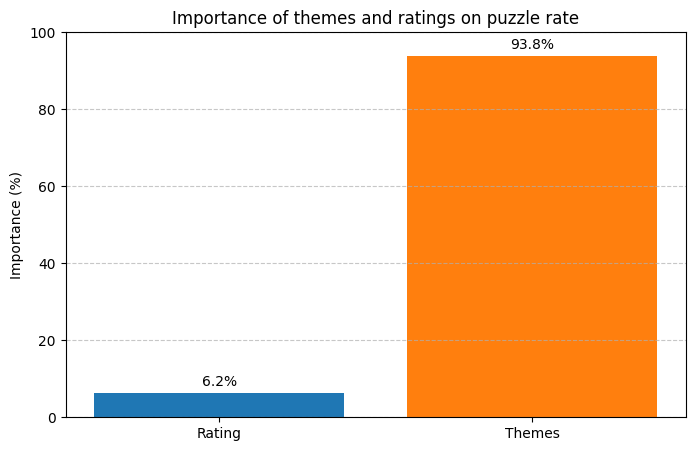

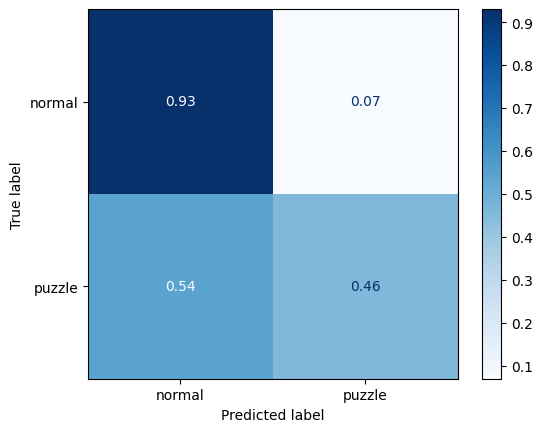

In [35]:
# df = pd.read_csv(Path("./Generate_positions/final_model/supervised/generated_positions/random_ratings.csv")).sample(n=200_000)
# df = pd.read_csv(Path("./Generate_positions/final_model/rl/full_diversity11_3500/test_context_no_move_lastv2.csv")).sample(n=200_000)
# df = pd.read_csv(Path("./Generate_positions/arxiv_true/test_move.csv"))
df = pd.read_csv(Path("./Generate_positions/arxiv_true/run22/model_0020000.csv"))

mlb = MultiLabelBinarizer()
themes_encoded = mlb.fit_transform(df["target_themes"].str.replace("'", "").str.replace("(", "").str.replace(")", "").str.split(", "))

theme_cols = mlb.classes_
df_themes = pd.DataFrame(themes_encoded, columns=theme_cols, index=df.index)

try:
    df_processed = pd.concat([df[["is_legal", "target_rating", 'is_puzzle', 'counter_intuitive_value', "counter_intuitive", "themes_match"]], df_themes], axis=1)
    # df_processed["score"] = df_processed["is_legal"] * df_processed["is_puzzle"].fillna(0) * df_processed["counter_intuitive"].fillna(0)
    df_processed["score"] = df_processed["is_legal"] * df_processed["is_puzzle"].fillna(0) * df_processed["counter_intuitive"].fillna(0) * df_processed["themes_match"].fillna(0)
except:
    df_processed = pd.concat([df[["is_legal", "target_rating", 'is_puzzle_true', "counter_intuitive_true", "themes_match"]], df_themes], axis=1)
    df_processed["score"] = df_processed["is_legal"] * df_processed["is_puzzle_true"].fillna(0) * df_processed["counter_intuitive_true"].fillna(0) * df_processed["themes_match"].fillna(0)

y = df_processed['score'].astype(np.int8)
X = df_processed[['target_rating'] + list(theme_cols)].astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=4,
    min_samples_split=2,
    min_samples_leaf=1, 
    class_weight='balanced',
    n_jobs=-1
)
model.fit(X_train, y_train)
print("Train score: ", balanced_accuracy_score(y_train, model.predict(X_train)))
print("Test score: ", balanced_accuracy_score(y_test, model.predict(X_test)))

importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})
rating, themes = 100 * importances[importances["Feature"] == "target_rating"]["Importance"].sum(), 100 * importances[importances["Feature"] != "target_rating"]["Importance"].sum()

percentages = [rating, themes]
labels = ['Rating', 'Themes']
colors = ['#1f77b4', '#ff7f0e']
print(list(zip(labels, percentages)))

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, percentages, color=colors)
plt.title(f'Importance of themes and ratings on puzzle rate')
plt.ylabel('Importance (%)')
plt.ylim(0, 100)
plt.bar_label(bars, fmt='%.1f%%', padding=3)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# plt.savefig("../Thesis/sections/figures/other/rating_theme_importance_supervised.pdf")
# plt.savefig("../Thesis/sections/figures/other/rating_theme_importance_rl.pdf")
# plt.savefig("./Generate_positions/arxiv_true/images/rating_theme_importance_supervised.pdf")
# plt.savefig("./Generate_positions/arxiv_true/images/rating_theme_importance_rl.pdf")
plt.show()

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    model.predict(X_test), 
    display_labels=['normal', 'puzzle'],
    cmap=plt.cm.Blues,
    normalize="true"  # "true" or None
)
plt.show()

In [ ]:
df = pd.read_csv(base_path / "run22" / "model_0020000.csv")

In [40]:
i = 0
n = 10
df[df["is_puzzle"] & df["themes_match"]].sort_values("counter_intuitive_value", ascending=False)[n * i: n * (i + 1)]

,target_themes,target_rating,fen,best_move,is_legal,is_puzzle,counter_intuitive,counter_intuitive_value,actual_themes,themes_match,main_line
135323,"('crushing', 'middlegame', 'short')",1709.0,8/3q3k/BPp1n2p/7Q/5p2/R1B1nP1P/6r1/7K w - - 3 46,e2d3,True,True,True,0.288000,"['middlegame', 'crushing', 'quietMove', 'short']",True,a6e2 e6g7 c3g7
113645,"('crushing', 'endgame', 'short')",1772.0,8/7k/1Qnr1p1p/6p1/2PPq3/1PPNp1PP/4K1P1/6R1 b - - 0 45,c6d4,True,True,True,0.288000,"['endgame', 'advantage', 'defensiveMove', 'long']",True,c6e5 b6c7 d6d7 c7d7 e5d7
175871,"('crushing', 'long', 'endgame', 'rookEndgame')",2484.0,2r5/8/2pk4/p1RP1ppp/1P6/P4KP1/7P/8 w - - 0 48,c5c6,True,True,True,0.288000,"['endgame', 'advantage', 'rookEndgame', 'short']",True,h2h4 g5h4 g3h4
195462,"('crushing', 'endgame', 'rookEndgame', 'master', 'veryLong', 'quietMove')",2080.0,2r3k1/p1P2ppp/8/1p6/8/2p1P3/5PPP/2R3K1 w - - 1 34,c1d1,True,True,True,0.272000,"['endgame', 'crushing', 'quietMove', 'rookEndgame', 'veryLong']",True,c1d1 g8f8 d1d8 f8e7 d8c8 e7d7 c8b8 d7c7 b8b5
25636,"('long', 'middlegame', 'mate', 'kingsideAttack', 'sacrifice', 'attraction', 'mateIn3')",1331.0,6rk/p1r2p1p/1p1q1p2/2pb1p2/5R1R/1P1PQ1P1/P1P1P2P/6K1 w - - 1 29,h4h7,True,True,True,0.260889,"['middlegame', 'mateIn3', 'mate', 'attraction', 'sacrifice', 'kingsideAttack', 'long']",True,h4h7 h8h7 f4h4 h7g6 e3h6
146958,"('crushing', 'endgame', 'fork', 'veryLong', 'pin', 'sacrifice', 'attraction')",1950.0,8/8/2n5/pK1Q4/P4rpk/1P6/2P5/8 b - - 3 99,f4f5,True,True,True,0.256000,"['endgame', 'crushing', 'attraction', 'sacrifice', 'fork', 'pin', 'long']",True,f4f5 d5f5 c6d4 b5b6 d4f5
138851,"('long', 'advantage', 'endgame', 'pin', 'sacrifice')",1928.0,3r2k1/p6p/1p3pp1/2pb1R2/8/P2BP2P/1PP3P1/6K1 w - - 0 23,f5d5,True,True,True,0.254667,"['endgame', 'advantage', 'sacrifice', 'pin', 'short']",True,f5d5 d8d5 d3c4
164485,"('endgame',)",574.0,6k1/8/6p1/2p5/2rp4/R1P2K2/4PP1P/8 b - - 1 44,c4c3,True,True,True,0.244889,"['endgame', 'crushing', 'rookEndgame', 'short']",True,c4c3 f3g4 c3a3
650,"('long', 'middlegame', 'mate', 'kingsideAttack', 'discoveredAttack', 'sacrifice', 'attraction', 'mateIn3', 'anastasiaMate')",1429.0,3r1rk1/pp3ppp/4n3/4PN2/2p5/2P1R3/qPQ2PPP/1N4K1 w - - 0 21,f5e7,True,True,True,0.240000,"['middlegame', 'mateIn3', 'mate', 'anastasiaMate', 'attraction', 'sacrifice', 'discoveredAttack', 'kingsideAttack', 'long']",True,f5e7 g8h8 c2h7 h8h7 e3h3
52207,"('long', 'middlegame', 'mate', 'kingsideAttack', 'sacrifice', 'attraction', 'mateIn3', 'doubleCheck')",2068.0,r3r1k1/pp3pp1/2qbpn2/7Q/3P3N/2P3P1/PP3P2/R1B3KR w - - 5 22,h5h8,True,True,True,0.240000,"['middlegame', 'mateIn3', 'mate', 'attraction', 'doubleCheck', 'sacrifice', 'kingsideAttack', 'long']",True,h5h8 g8h8 h4g6 h8g8 h1h8


In [ ]:
df = pd.read_csv("./Generate_positions/arxiv_true/old_rl_full_diversity11_3500.csv")

cols = {"legal": df["is_legal"], "unique": df["is_puzzle"], "counter-intuitive | unique": df[df["is_puzzle"]]["counter_intuitive"], "counter-intuitive-value | unique": df[df["is_puzzle"]]["counter_intuitive_value"], "puzzle": df["is_puzzle"] & df["counter_intuitive"], "themes match": df[~pd.isna(df["themes_match"])]["themes_match"], "themes match given puzzle": df[~pd.isna(df["themes_match"]) & df["counter_intuitive"]]["themes_match"], "puzzle & themes match": df["is_puzzle"] & df["counter_intuitive"] & df["themes_match"], "unique & themes match": df["is_puzzle"] & df["themes_match"]}
for name, col in cols.items():
    lower_bound, upper_bound = proportion_confint(count=col.sum(), nobs=len(col), alpha=0.05, method="normal")
    lower_bound, upper_bound = 100 * lower_bound, 100 * upper_bound
    print(name, 100 * col.mean(), [lower_bound, upper_bound], (upper_bound - lower_bound) / 2)


legal 99.76 [99.71711090029657, 99.80288909970344] 0.042889099703430134
unique 38.018 [37.5925088661997, 38.4434911338003] 0.4254911338002998
counter-intuitive | unique 2.2305223841338315 [2.020592920574548, 2.4404518476931147] 0.20992946355928344
counter-intuitive-value | unique 1.1262524768969078 [0.9762401896569982, 1.2762647641368172] 0.1500122872399095
puzzle 0.848 [0.7676267084671698, 0.9283732915328302] 0.08037329153283018
themes match 73.80545307297758 [72.98796372075738, 74.6229424251978] 0.817489352220214
themes match given puzzle 63.80090497737556 [57.46491866588139, 70.13689128886973] 6.335986311494171
puzzle & themes match 0.28200000000000003 [0.23551911133114656, 0.32848088866885344] 0.04648088866885344
unique & themes match 16.404 [16.079413302053453, 16.728586697946547] 0.3245866979465468


: 

0.00733010807295146 -0.0010408138522412856


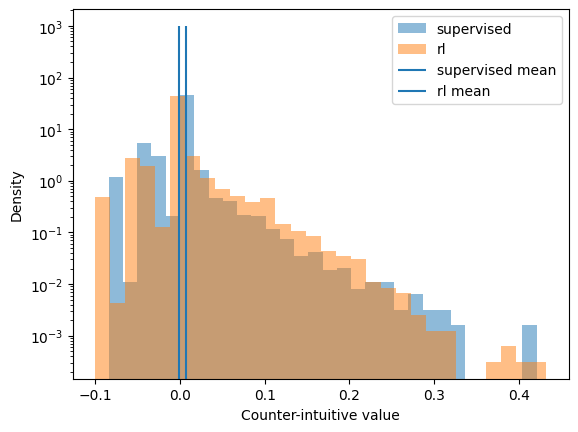

In [21]:
path = Path("./Generate_positions/arxiv_true/test_move.csv")
df_supervised = pd.read_csv(path)

# path = Path("./Generate_positions/arxiv_true/run22/model_0020000.csv")
path = Path("./Generate_positions/final_model/rl/full_diversity11_3500/test_context_no_move_lastv2.csv")
df_rl = pd.read_csv(path)

# col = df["is_puzzle"] & df["themes_match"] & df["counter_intuitive"]
col_supervised = df_supervised[df_supervised["is_puzzle"] & df_supervised["themes_match"]]["counter_intuitive_value"]
col_rl = df_rl[df_rl["is_puzzle"] & df_rl["themes_match"]]["counter_intuitive_value"]

print(col_supervised.mean(), col_rl.mean())
plt.hist(col_supervised, density=True, alpha=0.5, label="supervised", bins=30)
plt.hist(col_rl, density=True, alpha=0.5, label="rl", bins=30)
plt.vlines(col_supervised.mean(), 0, 1000, label="supervised mean")
plt.vlines(col_rl.mean(), 0, 1000, label="rl mean")
plt.yscale("log")
plt.xlabel("Counter-intuitive value")
plt.ylabel("Density")
plt.legend()
plt.show()



In [79]:
base_path = Path("./Generate_positions/arxiv_true/run22")
for path in natsorted(os.listdir(base_path)):
    if path[-4:] != ".csv" or path == "distances.csv" or path == "lichess.csv":
        continue
    df = pd.read_csv(base_path / path)

    print("=================== " + path[:-4] + " ===================")

    cols = {"legal": df["is_legal"], "unique": df["is_puzzle"], "counter-intuitive | unique": df[df["is_puzzle"]]["counter_intuitive"], "counter-intuitive-value | unique": df[df["is_puzzle"]]["counter_intuitive_value"], "puzzle": df["is_puzzle"] & df["counter_intuitive"], "themes match": df[~pd.isna(df["themes_match"])]["themes_match"], "themes match given puzzle": df[~pd.isna(df["themes_match"]) & df["counter_intuitive"]]["themes_match"], "puzzle & themes match": df["is_puzzle"] & df["counter_intuitive"] & df["themes_match"], "unique & themes match": df["is_puzzle"] & df["themes_match"]}
    for name, col in cols.items():
        lower_bound, upper_bound = proportion_confint(count=col.sum(), nobs=len(col), alpha=0.05, method="normal")
        lower_bound, upper_bound = 100 * lower_bound, 100 * upper_bound
        print(name, 100 * col.mean(), [lower_bound, upper_bound], (upper_bound - lower_bound) / 2)

    try:
        cols = {"unique true": df["is_puzzle_true"], "counter-intuitive true | unique true": df[df["is_puzzle_true"]]["counter_intuitive_true"], "puzzle true": df["is_puzzle_true"] & df["counter_intuitive_true"], "puzzle true & themes match": df["is_puzzle_true"] & df["counter_intuitive_true"] & df["themes_match"], "unique true & themes match": df["is_puzzle_true"] & df["themes_match"]}
        print("============")
        for name, col in cols.items():
            lower_bound, upper_bound = proportion_confint(count=col.sum(), nobs=len(col), alpha=0.05, method="normal")
            lower_bound, upper_bound = 100 * lower_bound, 100 * upper_bound
            print(name, 100 * col.mean(), [lower_bound, upper_bound], (upper_bound - lower_bound) / 2)
    except Exception:
        pass


=================== model_0000000 ===================
legal 98.96132319173364 [98.91273157341078, 99.0099148100565] 0.04859161832285963
unique 43.69080080367394 [43.453076777422964, 43.92852482992492] 0.23772402625097655
counter-intuitive | unique 0.9293095189215083 [0.859735645222531, 0.9988833926204855] 0.06957387369897727
counter-intuitive-value | unique 0.33793106594584676 [0.29585138820941903, 0.38001074368227444] 0.042079677736427706
puzzle 0.4060227707615768 [0.37554521514480854, 0.436500326378345] 0.030477555616768237
themes match 84.05338006335512 [83.71326463852986, 84.39349548818038] 0.3401154248252567
themes match given puzzle 66.84782608695652 [62.03806137298773, 71.6575908009253] 4.809764713968789
puzzle & themes match 0.14710103329506316 [0.12873241033208063, 0.16546965625804566] 0.018368622962982514
unique & themes match 22.371914466130885 [22.17218165609011, 22.571647276171657] 0.19973281004077315
=================== model_0005000 ===================
legal 99.916000000

In [19]:
# base_path = Path("./Generate_positions/final_model/supervised/first_time_move_found_division_50/")
# base_path = Path("./Generate_positions/final_model/supervised/generated_positions/")
# base_path = Path("./Generate_positions/final_model/rl/full_diversity11_3500/")
# base_path = Path("./Generate_positions/final_model/rl/full_diversity11/steps_experiment")
# base_path = Path("./Generate_positions/final_model/rl/full_diversity11/steps_experiment_own_theme_distribution")
base_path = Path("./Generate_positions/arxiv_true")
# base_path = Path("./Generate_positions/final_model_no_move/supervised/checkpoint1000000/")
# base_path = Path("./Generate_positions/final_model/rl/full_diversity18/checkpoint_20000")
for path in natsorted(os.listdir(base_path)):
    if path[-4:] != ".csv" or path == "distances.csv":
        continue
    df = pd.read_csv(base_path / path)

    print("=================== " + path[:-4] + " ===================")

    cols = {"legal": df["is_legal"], "unique": df["is_puzzle"], "counter-intuitive | unique": df[df["is_puzzle"]]["counter_intuitive"], "counter-intuitive-value | unique": df[df["is_puzzle"]]["counter_intuitive_value"], "puzzle": df["is_puzzle"] & df["counter_intuitive"], "themes match": df[~pd.isna(df["themes_match"])]["themes_match"], "themes match given puzzle": df[~pd.isna(df["themes_match"]) & df["counter_intuitive"]]["themes_match"], "puzzle & themes match": df["is_puzzle"] & df["counter_intuitive"] & df["themes_match"], "unique & themes match": df["is_puzzle"] & df["themes_match"]}
    for name, col in cols.items():
        lower_bound, upper_bound = proportion_confint(count=col.sum(), nobs=len(col), alpha=0.05, method="normal")
        lower_bound, upper_bound = 100 * lower_bound, 100 * upper_bound
        print(name, 100 * col.mean(), [lower_bound, upper_bound], (upper_bound - lower_bound) / 2)

    try:
        cols = {"unique true": df["is_puzzle_true"], "counter-intuitive true | unique true": df[df["is_puzzle_true"]]["counter_intuitive_true"], "puzzle true": df["is_puzzle_true"] & df["counter_intuitive_true"], "puzzle true & themes match": df["is_puzzle_true"] & df["counter_intuitive_true"] & df["themes_match"], "unique true & themes match": df["is_puzzle_true"] & df["themes_match"]}
        print("============")
        for name, col in cols.items():
            lower_bound, upper_bound = proportion_confint(count=col.sum(), nobs=len(col), alpha=0.05, method="normal")
            lower_bound, upper_bound = 100 * lower_bound, 100 * upper_bound
            print(name, 100 * col.mean(), [lower_bound, upper_bound], (upper_bound - lower_bound) / 2)
    except Exception:
        pass


=================== lichess ===================
legal 100.0 [100.0, 100.0] 0.0
unique 95.05550000000001 [94.96048702666565, 95.15051297333436] 0.09501297333435588
counter-intuitive | unique 2.3302176097122205 [2.2624030700687707, 2.3980321493556707] 0.06781453964344997
counter-intuitive-value | unique 1.0823802936179385 [1.0358676274220082, 1.1288929598138686] 0.0465126661959302
puzzle 2.215 [2.1505005400223696, 2.2794994599776306] 0.06449945997763051
themes match 94.57576448531833 [94.46404260668935, 94.68748636394733] 0.11172187862899108
themes match given puzzle 88.81385789782736 [87.75532026410028, 89.87239553155445] 1.0585376337270844
puzzle & themes match 1.5125 [1.4590101547324303, 1.5659898452675693] 0.0534898452675695
unique & themes match 74.66000000000001 [74.4693747653626, 74.85062523463742] 0.19062523463740888
=================== old_rl_full_diversity11_3500 ===================
legal 99.76 [99.71711090029657, 99.80288909970344] 0.042889099703430134
unique 38.018 [37.592508

In [26]:
base_path = Path("./Generate_positions/arxiv_true/run22")
for path in natsorted(os.listdir(base_path)):
    if path[-4:] != ".csv" or path == "distances.csv" or path == "lichess.csv":
        continue
    df = pd.read_csv(base_path / path)

    print("=================== " + path[:-4] + " ===================")

    cols = {"legal": df["is_legal"], "unique": df["is_puzzle"], "counter-intuitive | unique": df[df["is_puzzle"]]["counter_intuitive"], "counter-intuitive-value | unique": df[df["is_puzzle"]]["counter_intuitive_value"], "puzzle": df["is_puzzle"] & df["counter_intuitive"], "themes match": df[~pd.isna(df["themes_match"])]["themes_match"], "puzzle & themes match": df["is_puzzle"] & df["counter_intuitive"] & df["themes_match"], "unique & themes match": df["is_puzzle"] & df["themes_match"]}
    for name, col in cols.items():
        lower_bound, upper_bound = proportion_confint(count=col.sum(), nobs=len(col), alpha=0.05, method="normal")
        lower_bound, upper_bound = 100 * lower_bound, 100 * upper_bound
        print(name, 100 * col.mean(), [lower_bound, upper_bound], (upper_bound - lower_bound) / 2)

    try:
        cols = {"unique true": df["is_puzzle_true"], "counter-intuitive true | unique true": df[df["is_puzzle_true"]]["counter_intuitive_true"], "puzzle true": df["is_puzzle_true"] & df["counter_intuitive_true"], "puzzle true & themes match": df["is_puzzle_true"] & df["counter_intuitive_true"] & df["themes_match"], "unique true & themes match": df["is_puzzle_true"] & df["themes_match"]}
        print("============")
        for name, col in cols.items():
            lower_bound, upper_bound = proportion_confint(count=col.sum(), nobs=len(col), alpha=0.05, method="normal")
            lower_bound, upper_bound = 100 * lower_bound, 100 * upper_bound
            print(name, 100 * col.mean(), [lower_bound, upper_bound], (upper_bound - lower_bound) / 2)
    except Exception:
        pass


=================== model_0005000 ===================
legal 99.91600000000001 [99.90330331760649, 99.92869668239352] 0.012696682393517733
unique 62.788999999999994 [62.57715874187802, 63.000841258121966] 0.21184125812197152
counter-intuitive | unique 0.48734650973896704 [0.4488297811375155, 0.5258632383404186] 0.038516728601451555
counter-intuitive-value | unique 0.7435116908304876 [0.6959984489588377, 0.7910249327021375] 0.0475132418716499
puzzle 0.306 [0.28179370525306424, 0.3302062947469357] 0.024206294746935725
themes match 85.16155419222903 [84.92338223042975, 85.39972615402833] 0.23817196179928857
puzzle & themes match 0.1335 [0.11749765457553184, 0.14950234542446816] 0.016002345424468163
unique & themes match 36.438500000000005 [36.22758357211997, 36.649416427880034] 0.21091642788003284
=================== model_0010000 ===================
legal 99.9045 [99.8909628480335, 99.9180371519665] 0.013537151966502847
unique 65.54100000000001 [65.3327231695746, 65.7492768304254] 0.20827

In [ ]:
index = -1
path = Path("./Generate_positions/final_model/rl/full_diversity11_3500/test_context_no_move_lastv2.csv")
# df = pd.read_csv("./Generate_positions/final_model/supervised/test_context_move_last.csv")
df = pd.read_csv(path)
temp = df[df["is_legal"] & df["is_puzzle_true"] & df["counter_intuitive_true"] & df["themes_match"]].sort_values("counter_intuitive_value", ascending=False)

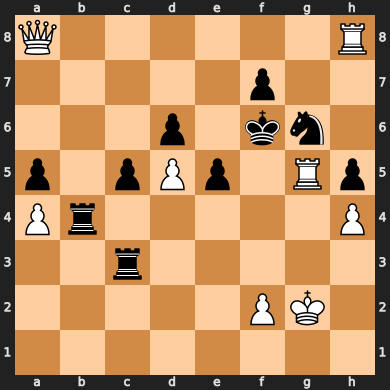

In [176]:
index = (index + 1) % len(temp)
row = temp.iloc[index]
board = chess.Board(row["fen"])
display(HTML(f"<h3>Puzzle {index + 1} / {len(temp)}</h3>"))
display(board)
display(HTML(f"<p style='font-size: 16px;'><b>Player to move:</b> {"white" if board.turn == chess.WHITE else "black"}</p>\n<p style='font-size: 16px;'><b>Solution:</b> {row['main_line']}</p>\n<p style='font-size: 16px;'><b>Themes:</b> {row['actual_themes'], row["target_themes"]}</p>\n<p style='font-size: 16px;'><b>FEN:</b> {row['fen']}</p>\n<p style='font-size: 16px;'><b>cnt values:</b> {row['counter_intuitive_value']}</p><hr>"))


In [74]:
# dataset = pd.read_csv("./dataset/dataset.csv", nrows=1000000)
dataset = pd.read_csv("./dataset/dataset.csv")

In [75]:
dataset["Padded_FEN"] = [fen_to_padded(x) for x in dataset["Puzzle_FEN"]]

In [76]:
# def closest_matches(fen, dataset, n = 3):
#     board_fen = fen_to_padded(fen)
#     distances = dataset["Puzzle_FEN"].apply(lambda x: Levenshtein.distance(fen_to_padded(x), board_fen))
#     smallest = distances.nsmallest(n)
#     closest_indices = smallest.index
#     return dataset.loc[closest_indices][["Puzzle_FEN", "Themes", "Rating", "Moves"]], smallest.values

def closest_matches(fen, dataset, n=3):
    board_fen = fen_to_padded(fen)
    distances = np.array([
        Levenshtein.distance(x, board_fen) 
        for x in dataset["Padded_FEN"]
    ])
    # board_fen = " ".join(fen[1].split(" ")[:4])
    # distances = np.array([
    #     Levenshtein.distance(" ".join(x.split(" ")[:4]), board_fen) 
    #     for x in dataset["Puzzle_FEN"]
    # ])
    # moves = fen[0]
    # distances = distances + np.array([
    #     Levenshtein.distance(x[5:], moves) for x in dataset["Moves"]
    # ])
    
    if len(distances) > n:
        closest_indices = np.argpartition(distances, n)[:n]
        
        closest_indices = closest_indices[np.argsort(distances[closest_indices])]
    else:
        closest_indices = np.argsort(distances)
        
    smallest_values = distances[closest_indices]
    
    cols_to_return = ["Puzzle_FEN", "Themes", "Rating", "Moves"]
    return dataset.iloc[closest_indices][cols_to_return], smallest_values

In [2]:
def print_puzzles(puzzles):
    with pd.option_context("display.max_colwidth", 500):
        display(puzzles)

In [4]:
def get_masked_squares(partial_fen: str) -> list[str]:
    masked_squares = []
    
    board_part = partial_fen.split(' ')[0] 
    ranks = board_part.split('/')
    
    for r_idx, rank_str in enumerate(ranks):
        rank_num = 8 - r_idx  # Ranks go 8, 7, 6, ..., 1
        
        for f_idx, char in enumerate(rank_str):
            if char == '?':
                file_char = chr(ord('a') + f_idx) # Files go a, b, c, ..., h
                masked_squares.append(f"{file_char}{rank_num}")
                
    return ", ".join(masked_squares)

In [ ]:
print(get_masked_squares(df.iloc[73043]["partial_fen_step_213"]))

a8, b8, c8, d8, e8, f8, g8, h8, a7, b7, c7, d7, e7, f7, g7, h7, c6, d6, e6, f6, g6, h6, a5, b5, c5, d5, e5, f5, g5, h5, a4, b4, c4, d4, h4, a3, b3, c3, d3, e3, f3, h3, b2, c2, d2, e2, f2, g2, h2, b1, d1, e1, f1, g1, h1


In [5]:
# path = Path("Generate_positions/final_model/rl/full_diversity11/partial_diffusion_positions_fork_underpromotion_endgame_promotion.csv")
path = Path("Generate_positions/final_model/rl/full_diversity11/diffusion_trajectories_short_and_wide.csv")
df = pd.read_csv(path)

In [6]:
100 * df["is_legal"].mean(), 100 * df["is_puzzle"].mean(), 100 * (df[df["is_puzzle"]]["counter_intuitive_value"] > 0.1).mean(), 100 * df["themes_match"].mean()

(np.float64(99.86979166666666),
 np.float64(24.531046549479164),
 np.float64(1.053286336305204),
 np.float64(81.44308521667011))

In [8]:
df[df["is_legal"] & df["is_puzzle"] & df["themes_match"] & (df["tree_id"] == 4)]["main_line"].apply(lambda x: x.split(" ")[0]).value_counts()

main_line
d5d6    37
d6d7    18
d6c7    16
d7g7    15
c6c7    12
c1c3    11
f6f7     6
d1d8     4
e6e7     2
b1b7     1
f3f7     1
e3f2     1
c3c1     1
b2b1     1
f3c3     1
e5e6     1
g2f1     1
c4c3     1
d1d6     1
g2g3     1
Name: count, dtype: int64

In [39]:
get_masked_squares("??.?.?k./?.??????/?p????../.???p?.?/...???r?/??.?????/Pr????P?/???R.R?. ? ?? ??")

'a8, b8, d8, f8, a7, c7, d7, e7, f7, g7, h7, a6, c6, d6, e6, f6, b5, c5, d5, f5, h5, d4, e4, f4, h4, a3, b3, d3, e3, f3, g3, h3, c2, d2, e2, f2, h2, a1, b1, c1, g1'

In [36]:
df.iloc[20233]["partial_fen_step_171"]

'??.?..??/?.????p?/?p??.?.p/????p.??/...???r?/P..?????/.r?????./???R??K. ? ??? ??'

In [38]:
df.iloc[19935]["partial_fen_step_171"]

'??.?.?k./?.??????/?p????../.???p?.?/...???r?/??.?????/Pr????P?/???R.R?. ? ?? ??'

In [ ]:
# steps 256, 171 128, 0
# steps 256, 213 128, 0

In [44]:
df.columns

Index(['tree_id', 'trajectory_id', 'target_themes', 'target_rating', 'fen',
       'is_legal', 'is_puzzle', 'best_move', 'main_line', 'actual_themes',
       'themes_match', 'counter_intuitive_value', 'node_id_step_256',
       'partial_fen_step_256', 'unmasked_count_step_256', 'node_id_step_213',
       'partial_fen_step_213', 'unmasked_count_step_213', 'node_id_step_171',
       'partial_fen_step_171', 'unmasked_count_step_171', 'node_id_step_128',
       'partial_fen_step_128', 'unmasked_count_step_128', 'node_id_step_85',
       'partial_fen_step_85', 'unmasked_count_step_85', 'node_id_step_43',
       'partial_fen_step_43', 'unmasked_count_step_43', 'node_id_step_0',
       'partial_fen_step_0', 'unmasked_count_step_0'],
      dtype='object')

In [32]:
df[df["is_legal"] & df["is_puzzle"] & df["themes_match"] & (df["tree_id"] == 4) & (df["node_id_step_213"] == "0_3")]["main_line"].apply(lambda x: x.split(" ")[0]).value_counts()

main_line
d7g7    15
d6c7     6
f6f7     6
d1d8     4
d5d6     2
d1d6     1
g2f1     1
e6e7     1
c6c7     1
d6d7     1
g2g3     1
Name: count, dtype: int64

In [41]:
df[df["tree_id"] == 4].iloc[0]["target_themes"]

"('crushing', 'long', 'endgame', 'rookEndgame', 'advancedPawn')"

In [33]:
print_puzzles(df[df["is_legal"] & df["is_puzzle"] & df["themes_match"] & (df["tree_id"] == 4) & (df["node_id_step_213"] == "0_3")].sort_values("counter_intuitive_value", ascending=False))

,tree_id,trajectory_id,target_themes,target_rating,fen,is_legal,is_puzzle,best_move,main_line,actual_themes,...,unmasked_count_step_128,node_id_step_85,partial_fen_step_85,unmasked_count_step_85,node_id_step_43,partial_fen_step_43,unmasked_count_step_43,node_id_step_0,partial_fen_step_0,unmasked_count_step_0
20383,4,tree_4_0_3_3_2_1_3_3,"('crushing', 'long', 'endgame', 'rookEndgame', 'advancedPawn')",2500.0,6k1/6p1/1p3P1p/1ppPp2P/6r1/P4R2/1r4P1/3R2K1 w - - 1 34,True,True,d5d6,g2g3 g7f6 d5d6 g8f7 d6d7,"['endgame', 'advantage', 'advancedPawn', 'quietMove', 'rookEndgame', 'long']",...,43,0_3_3_2_1,...?..??/..??.?p./.p?..P.p/.ppPp..P/.....?r?/P..??R.?/.r.?..?./.?.R.?K. w ?? -,57,0_3_3_2_1_3,...?..k./...?..p./.p...P.p/.ppPp..P/......r./P...?R.?/.r....?./.?.R.?K. w ? -,70,0_3_3_2_1_3_3,......k./......p./.p...P.p/.ppPp..P/......r./P....R../.r....P./...R..K. w - -,81
20233,4,tree_4_0_3_3_0_0_2_1,"('crushing', 'long', 'endgame', 'rookEndgame', 'advancedPawn')",2500.0,6k1/3R2p1/1pp2P1p/pPp1p3/6rP/P7/1r4P1/3R2K1 w - - 1 33,True,True,d7d8,d7g7 g4g7 d1d8 g8h7 f6g7,"['endgame', 'crushing', 'advancedPawn', 'sacrifice', 'rookEndgame', 'long']",...,43,0_3_3_0_0,?..?..k?/..?R??p./?p?..?.p/??p?p.../......rP/P..?????/.r?.?.P./...R..K. w ? ??,55,0_3_3_0_0_2,...?..k?/...R.?p./?p?..P.p/??p?p.../......rP/P..???.?/.r?...P./...R..K. w ? -,64,0_3_3_0_0_2_1,......k./...R..p./.pp..P.p/pPp.p.../......rP/P......./.r....P./...R..K. w - -,81
19935,4,tree_4_0_3_1_3_1_3_3,"('crushing', 'long', 'endgame', 'rookEndgame', 'advancedPawn')",2500.0,6k1/p1p4p/1p2P3/2p1p3/6rp/8/Pr3PP1/3R1RK1 w - - 0 36,True,True,d1d8,d1d8 g8g7 e6e7,"['endgame', 'crushing', 'advancedPawn', 'rookEndgame', 'short']",...,36,0_3_1_3_1,.?.?..k./p.??.?.?/.p??P?../.?p?p?.?/....??r?/??..?.??/Pr????P./??.R.RK. w - ??,47,0_3_1_3_1_3,.?.?..k./p.?....?/.p?.P.../.?p?p?../....?.r?/.?....??/Pr???PP./??.R.RK. w - -,59,0_3_1_3_1_3_3,......k./p.p....p/.p..P.../..p.p.../......rp/......../Pr...PP./...R.RK. w - -,81
19603,4,tree_4_0_3_0_2_1_0_3,"('crushing', 'long', 'endgame', 'rookEndgame', 'advancedPawn')",2500.0,8/3R4/1p2k2P/1pp1p3/5rr1/5P2/Pr4P1/3R2K1 w - - 13 48,True,True,d1d6,d1d6 e6f5 d7f7 f5g5 f7g7 g5h4 g7g4 f4g4 f3g4 b2a2 h6h7 a2a8 d6h6,"['endgame', 'advantage', 'advancedPawn', 'skewer', 'clearance', 'rookEndgame', 'veryLong']",...,34,0_3_0_2_1,?..?.?../?..R.?../?p?.?..?/?pp.p??./....??r?/.?...???/?r....?./.??R..?. w - ??,48,0_3_0_2_1_0,......../?..R.?../?p..?..?/?pp.p??./....?rr./.?...P?./?r....?./.?.R..?. w - ??,61,0_3_0_2_1_0_3,......../...R..../.p..k..P/.pp.p.../.....rr./.....P../Pr....P./...R..K. w - -,81
20391,4,tree_4_0_3_3_2_2_1_3,"('crushing', 'long', 'endgame', 'rookEndgame', 'advancedPawn')",2500.0,6k1/3R2p1/1p3P1p/2pPp2P/6r1/P7/1r4P1/3R2K1 w - - 1 33,True,True,d7g7,d7g7 g4g7 f6g7,"['endgame', 'crushing', 'advancedPawn', 'rookEndgame', 'short']",...,43,0_3_3_2_2,......k./..?R??p./?p...P.p/??pPp.?P/.....?r./P...????/.r.??.P./...R.?K. w ? ??,56,0_3_3_2_2_1,......k./..?R.?p./.p...P.p/?.pPp.?P/.....?r./P...??../.r.??.P./...R.?K. w - -,65,0_3_3_2_2_1_3,......k./...R..p./.p...P.p/..pPp..P/......r./P......./.r....P./...R..K. w - -,81
20392,4,tree_4_0_3_3_2_2_2_0,"('crushing', 'long', 'endgame', 'rookEndgame', 'advancedPawn')",2500.0,6k1/3R2p1/1p3P1p/1ppPp2P/6r1/P7/1r4P1/3R2K1 w - - 2 33,True,True,d7d8,d7g7 g4g7 f6g7,"['endgame', 'crushing', 'advancedPawn', 'rookEndgame', 'short']",...,43,0_3_3_2_2,......k./..?R??p./?p...P.p/??pPp.?P/.....?r./P...????/.r.??.P./...R.?K. w ? ??,56,0_3_3_2_2_2,......k./..?R.?p./?p...P.p/.?pPp..P/......r./P.....?./.r.?..P./...R..K. w ? ??,67,0_3_3_2_2_2_0,......k./...R..p./.p...P.p/.ppPp..P/......r./P......./.r....P./...R..K. w - -,81
20395,4,tree_4_0_3_3_2_2_2_3,"('crushing', 'long', 'endgame', 'rookEndgame', 'advancedPawn')",2500.0,6k1/3R2p1/1p3P1p/2pPp2P/6r1/P7/1r4P1/3R2K1 w - - 12 33,True,True,d7d8,d7g7 g4g7 f6g7 b2a2 d5d6 a2a3 d6d7,"['endgame', 'crushing', 'advancedPawn', 'rookEndgame', 'veryLong']",...,43,0_3_3_2_2,......k./..?R??p./?p...P.p/??pPp.?P/.....?r./